# Operations with Limits

This notebook follows the same style as the previous notebooks and explains the main **operations with limits**.

It covers:

- sum rule
- difference rule
- product rule
- quotient rule
- multiplication by a constant
- powers
- roots
- a worked example
- Python and SymPy checks


## 1. Why operations with limits matter

If we already know the limits of simpler functions, then we can often build the limit of a more complicated function from them.

This is one of the main practical tools in limit computations.


## 2. General setup

Suppose we have two functions $f(x)$ and $g(x)$, and both limits exist:

$$
\lim_{x\to a} f(x), \qquad \lim_{x\to a} g(x).
$$

Then we can perform several algebraic operations with these limits.


## 3. Sum rule

If both limits exist, then:

$$
\lim_{x\to a} f(x) + \lim_{x\to a} g(x)
=
\lim_{x\to a} (f(x)+g(x)).
$$

In short:

> the limit of a sum is the sum of the limits.


In [1]:
import sympy as sp
x = sp.symbols('x')

f = x**2
g = 3*x + 1

lhs = sp.limit(f, x, 2) + sp.limit(g, x, 2)
rhs = sp.limit(f + g, x, 2)

print("LHS =", lhs)
print("RHS =", rhs)


LHS = 11
RHS = 11


## 4. Difference rule

Similarly:

$$
\lim_{x\to a} f(x) - \lim_{x\to a} g(x)
=
\lim_{x\to a} (f(x)-g(x)).
$$

So:

> the limit of a difference is the difference of the limits.


In [2]:
lhs = sp.limit(f, x, 2) - sp.limit(g, x, 2)
rhs = sp.limit(f - g, x, 2)

print("LHS =", lhs)
print("RHS =", rhs)


LHS = -3
RHS = -3


## 5. Product rule

If both limits exist, then:

$$
\left(\lim_{x\to a} f(x)\right)
\left(\lim_{x\to a} g(x)\right)
=
\lim_{x\to a} (f(x)g(x)).
$$

So:

> the limit of a product is the product of the limits.


In [3]:
lhs = sp.limit(f, x, 2) * sp.limit(g, x, 2)
rhs = sp.limit(f * g, x, 2)

print("LHS =", lhs)
print("RHS =", rhs)


LHS = 28
RHS = 28


## 6. Quotient rule

If

$$
\lim_{x\to a} g(x) \ne 0,
$$

then

$$
\frac{\lim_{x\to a} f(x)}{\lim_{x\to a} g(x)}
=
\lim_{x\to a} \frac{f(x)}{g(x)}.
$$

So:

> the limit of a quotient is the quotient of the limits, provided the denominator limit is not zero.


In [4]:
f = x**2 + 1
g = x + 3

lhs = sp.limit(f, x, 1) / sp.limit(g, x, 1)
rhs = sp.limit(f/g, x, 1)

print("LHS =", lhs)
print("RHS =", rhs)


LHS = 1/2
RHS = 1/2


### Important warning

The quotient rule requires:

$$
\lim_{x\to a} g(x) \ne 0.
$$

If the denominator limit is 0, the rule cannot be applied directly.


In [5]:
f = x**2 - 1
g = x - 1

print("Numerator limit at x->1:", sp.limit(f, x, 1))
print("Denominator limit at x->1:", sp.limit(g, x, 1))
print("Direct quotient rule does not apply because denominator limit is 0.")
print("But the full limit may still exist:", sp.limit(f/g, x, 1))


Numerator limit at x->1: 0
Denominator limit at x->1: 0
Direct quotient rule does not apply because denominator limit is 0.
But the full limit may still exist: 2


## 7. Multiplication by a constant

For a constant $c$:

$$
c \cdot \lim_{x\to a} f(x)
=
\lim_{x\to a} (c f(x)).
$$


In [6]:
c = 5
f = x**2 - 3

lhs = c * sp.limit(f, x, 2)
rhs = sp.limit(c * f, x, 2)

print("LHS =", lhs)
print("RHS =", rhs)


LHS = 5
RHS = 5


## 8. Powers

If the limit exists, then for a positive integer $n$:

$$
\left(\lim_{x\to a} f(x)\right)^n
=
\lim_{x\to a} (f(x))^n.
$$


In [7]:
f = x + 2
n = 3

lhs = sp.limit(f, x, 1)**n
rhs = sp.limit(f**n, x, 1)

print("LHS =", lhs)
print("RHS =", rhs)


LHS = 27
RHS = 27


## 9. Roots

If the root makes sense near the point, then:

$$
\sqrt[n]{\lim_{x\to a} f(x)}
=
\lim_{x\to a} \sqrt[n]{f(x)}.
$$

For example, with square roots we usually need nonnegative values.


In [8]:
f = x + 3

lhs = sp.sqrt(sp.limit(f, x, 1))
rhs = sp.limit(sp.sqrt(f), x, 1)

print("LHS =", lhs)
print("RHS =", rhs)


LHS = 2
RHS = 2


## 10. Worked example from the lesson

Compute:

$$
\lim_{x\to 1} \frac{x^4 - 3x^2 + 1}{4-x}.
$$

Using limit rules:

$$
\lim_{x\to 1} \frac{x^4 - 3x^2 + 1}{4-x}
=
\frac{\lim_{x\to 1}(x^4 - 3x^2 + 1)}{\lim_{x\to 1}(4-x)}
$$

because the denominator limit is not zero.


Now evaluate numerator and denominator separately:

$$
\lim_{x\to 1}(x^4 - 3x^2 + 1)
=
\lim_{x\to 1}x^4 - 3\lim_{x\to 1}x^2 + \lim_{x\to 1}1
$$

$$
= 1^4 - 3\cdot 1^2 + 1 = -1
$$

and

$$
\lim_{x\to 1}(4-x)=4-1=3.
$$

So the limit is:

$$
\frac{-1}{3}.
$$


In [9]:
expr = (x**4 - 3*x**2 + 1) / (4 - x)
sp.limit(expr, x, 1)


-1/3

## 11. Numerical check of the worked example

Let's verify numerically with values close to 1.


In [10]:
import numpy as np

def h(x):
    return (x**4 - 3*x**2 + 1) / (4 - x)

xs = [0.9, 0.99, 0.999, 1.001, 1.01, 1.1]
for val in xs:
    print(f"x = {val}, h(x) = {h(val)}")


x = 0.9, h(x) = -0.24964516129032266
x = 0.99, h(x) = -0.3254830531561461
x = 0.999, h(x) = -0.332554816394202
x = 1.001, h(x) = -0.33411036878926287
x = 1.01, h(x) = -0.341035448160535
x = 1.1, h(x) = -0.4020344827586209


These values are close to

$$
-\frac13 \approx -0.333333\dots
$$


## 12. A visual check

We can also plot the function near $x=1$.


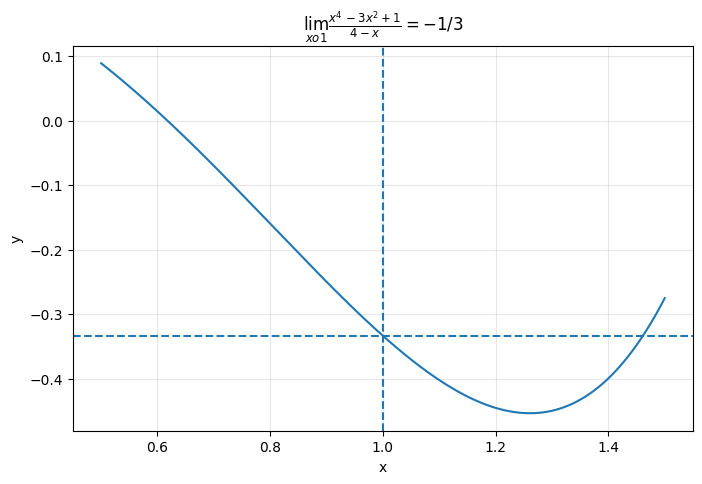

In [11]:
import matplotlib.pyplot as plt

xs = np.linspace(0.5, 1.5, 400)
ys = (xs**4 - 3*xs**2 + 1) / (4 - xs)

plt.figure(figsize=(8,5))
plt.plot(xs, ys)
plt.axhline(-1/3, linestyle='--')
plt.axvline(1, linestyle='--')
plt.title(r"$\lim_{x	o1}\frac{x^4-3x^2+1}{4-x}=-1/3$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()


## 13. Combining several rules

Let us compute:

$$
\lim_{x\to 2} \left( 3x^2 - 2x + 5 \right).
$$

Using the sum, difference, constant multiple, and power rules:

$$
= 3\lim_{x\to 2} x^2 - 2\lim_{x\to 2} x + 5
$$

$$
= 3(2^2) - 2(2) + 5 = 12 - 4 + 5 = 13.
$$


In [12]:
expr = 3*x**2 - 2*x + 5
sp.limit(expr, x, 2)


13

## 14. Example with a square root

Compute:

$$
\lim_{x\to 1} \sqrt{x+3}.
$$

Since $x+3 \to 4$, we get:

$$
\lim_{x\to 1}\sqrt{x+3} = \sqrt{4} = 2.
$$


In [14]:
expr = sp.sqrt(x + 3)
sp.limit(expr, x, 1)


2

## 15. Example where direct rules do not apply immediately

Consider:

$$
\lim_{x\to 1} \frac{x^2-1}{x-1}.
$$

If we try the quotient rule directly, both numerator and denominator go to 0, so the rule cannot be used as-is.

But we can simplify:

$$
\frac{x^2-1}{x-1} = \frac{(x-1)(x+1)}{x-1}=x+1
$$

for $x \ne 1$.

So the limit is:

$$
2.
$$


In [13]:
expr = (x**2 - 1)/(x - 1)

print("Direct limit:", sp.limit(expr, x, 1))
print("Simplified expression:", sp.simplify(expr))


Direct limit: 2
Simplified expression: x + 1


## 16. Summary table of the rules

If the relevant limits exist, then:

### Sum
$$
\lim(f+g)=\lim f + \lim g
$$

### Difference
$$
\lim(f-g)=\lim f - \lim g
$$

### Product
$$
\lim(fg)= (\lim f)(\lim g)
$$

### Quotient
$$
\lim\left(\frac{f}{g}\right)=\frac{\lim f}{\lim g}
\quad \text{if } \lim g \ne 0
$$

### Constant multiple
$$
\lim(cf)=c\lim f
$$

### Power
$$
\lim(f^n)=(\lim f)^n
$$

### Root
$$
\lim(\sqrt[n]{f})=\sqrt[n]{\lim f}
$$


## 17. Small exercises

1. Compute:
$$
\lim_{x\to 2}(x^2+3x)
$$

2. Compute:
$$
\lim_{x\to 1}\frac{x+2}{x+5}
$$

3. Compute:
$$
\lim_{x\to 4} \sqrt{x}
$$

4. Explain why the quotient rule cannot be used directly for
$$
\lim_{x\to 1}\frac{x^2-1}{x-1}.
$$


In [14]:
print("1.", sp.limit(x**2 + 3*x, x, 2))
print("2.", sp.limit((x+2)/(x+5), x, 1))
print("3.", sp.limit(sp.sqrt(x), x, 4))
print("4. Because both numerator and denominator tend to 0, so the denominator limit is not nonzero.")


1. 10
2. 1/2
3. 2
4. Because both numerator and denominator tend to 0, so the denominator limit is not nonzero.


## 18. Conclusion

You learned the main algebraic operations with limits:

- addition
- subtraction
- multiplication
- division (when the denominator limit is not zero)
- multiplication by a constant
- powers
- roots

These rules are among the most useful tools for calculating limits efficiently.
